In [2]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations
import sys

sys.path.append("../../")


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB


In [4]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [5]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [6]:
df__ = dt.add_pca_df(df_)

In [7]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [9]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2.5, win=10, event_onset=(100, 500))
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

df_tr['disturb_sum'] = df_tr['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

# Add instantaneous phase
disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.58
Dropped 65 of 333 rows (19.52%).


In [28]:
sorted_disturbances

array([-36.37116736, -29.69397808, -22.94078642, -20.3322972 ,
       -18.93022048, -18.1618848 , -17.94052   , -17.83545964,
       -16.87240787, -14.75419727, -14.5140413 , -12.81418324,
       -11.81221732, -11.80358844, -11.45712489, -11.21468874,
       -10.64105726, -10.63700005, -10.30265856, -10.20974094,
        -9.80588887,  -9.69902865,  -9.60841176,  -9.58554361,
        -9.3556158 ,  -9.26814159,  -9.18069229,  -9.07903468,
        -8.91252944,  -8.89779852,  -8.81554314,  -8.75272029,
        -8.74501336,  -8.69008319,  -8.57961721,  -8.47186126,
        -8.36825211,  -8.36489734,  -8.08243303,  -8.05894648,
        -8.0530265 ,  -8.00791584,  -7.62653939,  -7.56919509,
        -7.29507993,  -7.24899822,  -7.15651814,  -7.08199562,
        -7.07523957,  -7.03753001,  -7.02313748,  -6.99051749,
        -6.92986819,  -6.92005967,  -6.85164408,  -6.85103463,
        -6.71738483,  -6.71121734,  -6.62062784,  -6.54156143,
        -6.3651145 ,  -6.20949203,  -6.1861311 ,  -6.17

## Disturbance Score — Presentation Figures

The **disturbance score** quantifies how much a solenoid perturbation disrupts the animal's locomotion rhythm.

**Pipeline recap:**
1. Compute Morlet wavelet power at the dominant pre-perturbation gait frequency for each keypoint (vertical z-coordinate).
2. Baseline-subtract (mean of pre-perturbation window).
3. Integrate the post-perturbation power → one scalar per keypoint per trial.
4. Negative values = power dropped = locomotion was disrupted.

`disturb_sum = log₁₀(|Σ_keypoints disturb_score|)` — a single scalar per trial used as the disturbance magnitude.


In [10]:
## ── Shared plot style ──────────────────────────────────────────────────────
PRES_RC = {
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 120,
    "lines.linewidth": 2.0,
}

# handy sorted arrays  (sorted by *signed* summed disturbance, most negative first)
# subset: ranks 2–200 (index 1:200) to exclude the single extreme outlier
_idx = dstrb_idx[1:200]

sorted_disturbances = disturbances[_idx]                               # signed scalar per trial
sorted_dirs         = df_tr["values_Sol_direction"].values[_idx]
sorted_angles       = np.array([Params.sol_dir_to_angle[d] for d in sorted_dirs])
sorted_disturb_sum  = df_tr["disturb_sum"].values[_idx]                # log10(|Σ|) per trial
sorted_laterality   = np.array([Params.sol_dir_to_contra_ipse[d] for d in sorted_dirs])
x_sorted            = np.arange(len(_idx))

# per-keypoint matrix (n_trials × n_keypoints), already sorted
score_mat = np.stack(df_tr["disturb_score"].values)[_idx]              # (n_trials, 12)


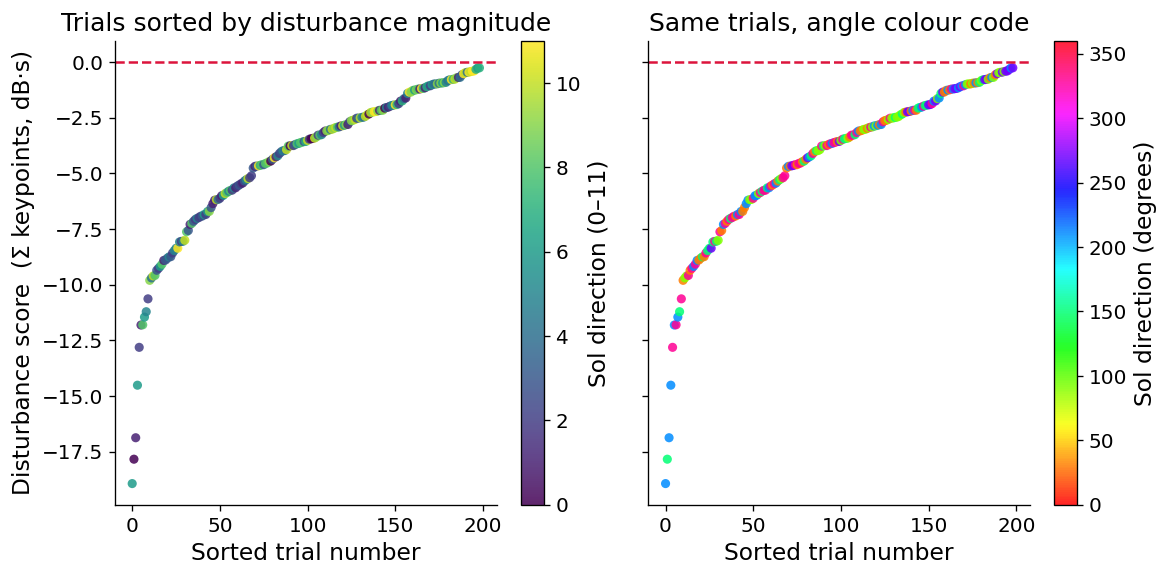

In [11]:
## ── Fig 1 · Sorted scatter coloured by perturbation direction ──────────────
with mpl.rc_context(PRES_RC):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    # left: colour = direction integer (0-11)
    sc = axes[0].scatter(
        x_sorted, sorted_disturbances,
        c=sorted_dirs, cmap="viridis", s=30, alpha=0.85, linewidths=0,
    )
    axes[0].axhline(0, color="crimson", linestyle="--", linewidth=1.5, label="baseline")
    cb = plt.colorbar(sc, ax=axes[0])
    cb.set_label("Sol direction (0–11)")
    axes[0].set_xlabel("Sorted trial number")
    axes[0].set_ylabel("Disturbance score  (Σ keypoints, dB·s)")
    axes[0].set_title("Trials sorted by disturbance magnitude")

    # right: colour = direction angle (degrees)
    sc2 = axes[1].scatter(
        x_sorted, sorted_disturbances,
        c=sorted_angles, cmap="hsv", vmin=0, vmax=360,
        s=30, alpha=0.85, linewidths=0,
    )
    axes[1].axhline(0, color="crimson", linestyle="--", linewidth=1.5)
    cb2 = plt.colorbar(sc2, ax=axes[1])
    cb2.set_label("Sol direction (degrees)")
    axes[1].set_xlabel("Sorted trial number")
    axes[1].set_title("Same trials, angle colour code")

    fig.tight_layout()
    plt.show()


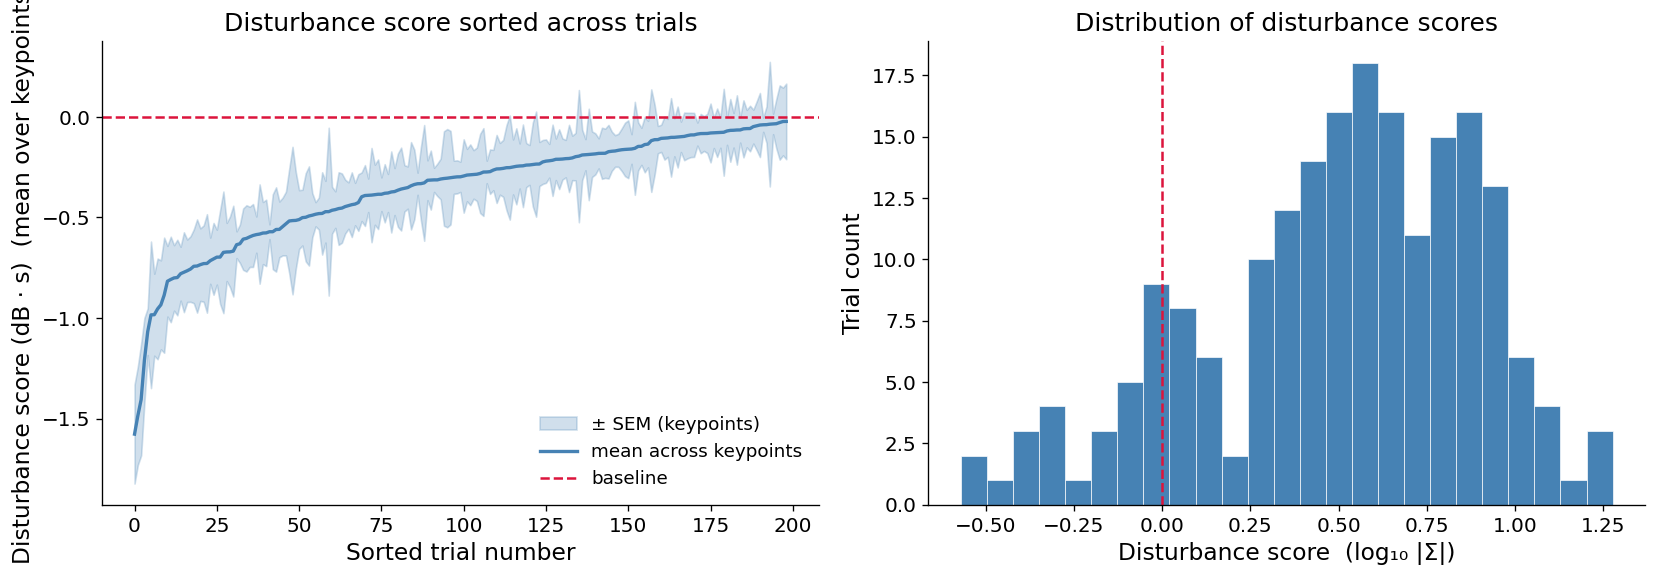

In [12]:
## ── Fig 2 · Mean ± SEM envelope + histogram ─────────────────────────────────
# mean & SEM of disturb_score *across keypoints* for each sorted trial
kp_mean = score_mat.mean(axis=1)   # (n_trials,)
kp_sem  = score_mat.std(axis=1) #/ np.sqrt(score_mat.shape[1])

with mpl.rc_context(PRES_RC):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # left: sorted mean ± SEM across keypoints
    ax = axes[0]
    ax.fill_between(x_sorted, kp_mean - kp_sem, kp_mean + kp_sem,
                    alpha=0.25, color="steelblue", label="± SEM (keypoints)")
    ax.plot(x_sorted, kp_mean, color="steelblue", lw=2, label="mean across keypoints")
    ax.axhline(0, color="crimson", linestyle="--", lw=1.5, label="baseline")
    ax.set_xlabel("Sorted trial number")
    ax.set_ylabel("Disturbance score (dB · s)  (mean over keypoints)")
    ax.set_title("Disturbance score sorted across trials")
    ax.legend(frameon=False, fontsize=11)

    # right: histogram of per-trial disturb_sum
    ax = axes[1]
    ax.hist(sorted_disturb_sum, bins=25, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="crimson", linestyle="--", lw=1.5)
    ax.set_xlabel("Disturbance score  (log₁₀ |Σ|)")
    ax.set_ylabel("Trial count")
    ax.set_title("Distribution of disturbance scores")

    fig.tight_layout()
    plt.show()


/tmp/ipykernel_1097239/3606375804.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


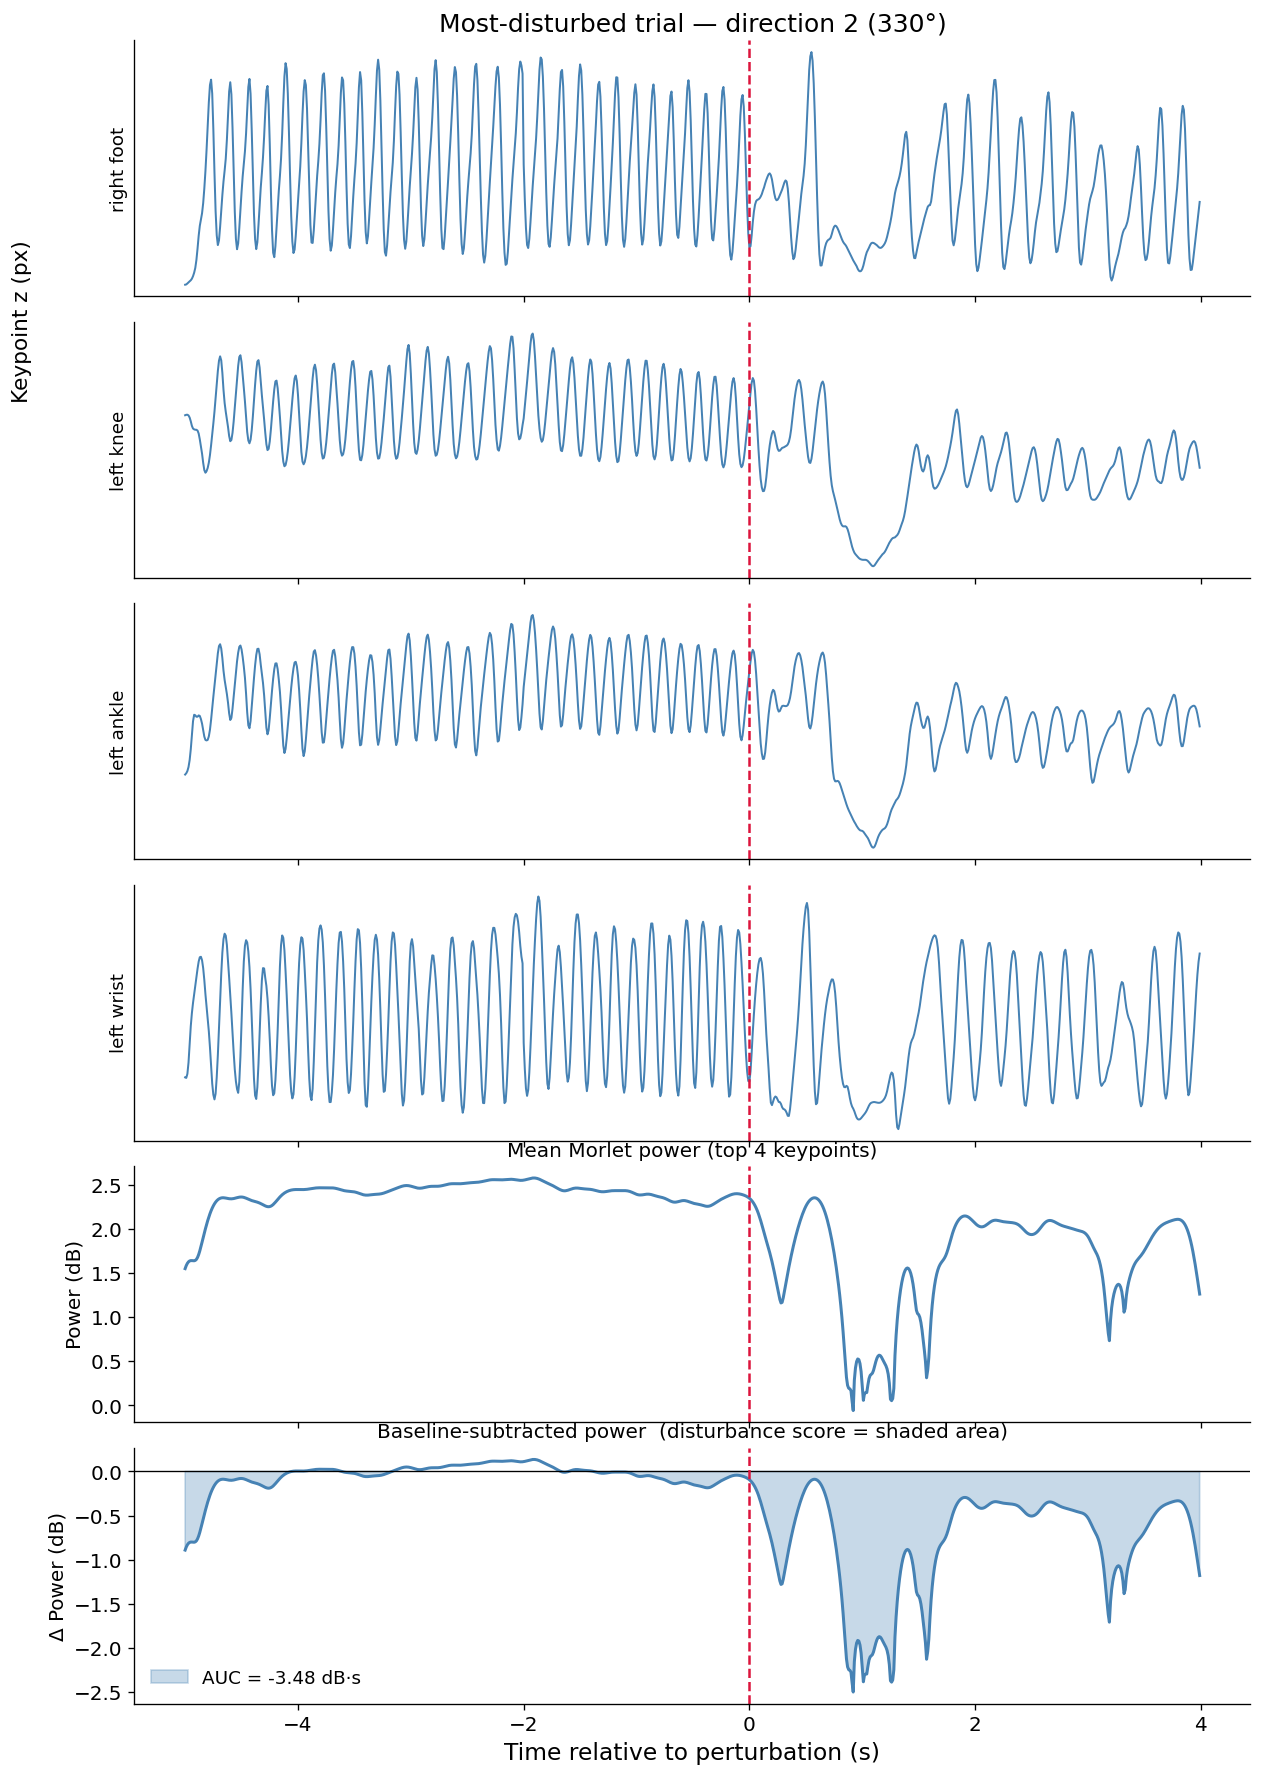

In [13]:
## ── Fig 3 · Single-trial example: kinematics traces + Morlet power ──────────
BIN_KIN  = 0.01   # 10 ms kinematics bins
N_SHOW   = 4      # keypoints to display

trial_row = df_tr.iloc[dstrb_idx[0]]   # most-disturbed trial
bhv_arr   = trial_row.bhv_concat        # (T_concat, 12)
pwr_arr   = trial_row.power             # (T_concat, 12)
p_idx     = trial_row.concat_perturb_time
t_start   = trial_row.concat_trial_start
T         = bhv_arr.shape[0]
t_axis    = (np.arange(T) - p_idx) * BIN_KIN

# baseline-subtract power the same way compute_perturb_disturb_score does
baseline_mean = pwr_arr[100:p_idx, :].mean(axis=0, keepdims=True)
pwr_norm      = pwr_arr - baseline_mean     # (T, 12)

# pick the 4 most-disrupted keypoints for illustration
top_kp = np.argsort(pwr_norm[p_idx: p_idx+200, :].mean(0))[:N_SHOW]
kp_labels = [ALL_BHV_FIELDS[i] for i in top_kp]

with mpl.rc_context(PRES_RC):
    fig, axes = plt.subplots(N_SHOW + 2, 1, figsize=(12, 3 * (N_SHOW + 2)),
                              sharex=True, gridspec_kw={"hspace": 0.1})

    # ── kinematics traces ─────────────────────────────────────────────────
    for row_i, kp_i in enumerate(top_kp):
        ax = axes[row_i]
        ax.plot(t_axis, bhv_arr[:, kp_i], color="steelblue", lw=1.2)
        ax.axvline(0, color="crimson", linestyle="--", lw=1.5)
        ax.set_ylabel(kp_labels[row_i].replace("_", " "), fontsize=11)
        ax.set_yticks([])

    axes[0].set_title(
        f"Most-disturbed trial — direction {int(trial_row.values_Sol_direction)}"
        f" ({Params.sol_dir_to_angle[int(trial_row.values_Sol_direction)]}°)",
    )
    fig.text(0.04, 0.75, "Keypoint z (px)", va="center", rotation="vertical", fontsize=13)

    # ── raw Morlet power ──────────────────────────────────────────────────
    ax_pwr = axes[N_SHOW]
    mean_pwr = pwr_arr[:, top_kp].mean(axis=1)
    ax_pwr.plot(t_axis, mean_pwr, color="steelblue", lw=1.8)
    ax_pwr.axvline(0, color="crimson", linestyle="--", lw=1.5)
    ax_pwr.set_ylabel("Power (dB)", fontsize=12)
    ax_pwr.set_title("Mean Morlet power (top 4 keypoints)", fontsize=12)

    # ── baseline-subtracted power with AUC fill ───────────────────────────
    ax_norm = axes[N_SHOW + 1]
    mean_norm = pwr_norm[:, top_kp].mean(axis=1)
    ax_norm.plot(t_axis, mean_norm, color="steelblue", lw=1.8)
    ax_norm.fill_between(t_axis, mean_norm, 0,
                         where=(mean_norm < 0), alpha=0.3, color="steelblue",
                         label=f"AUC = {mean_norm.sum() * BIN_KIN:.2f} dB·s")
    ax_norm.axhline(0, color="black", lw=0.8, linestyle="-")
    ax_norm.axvline(0, color="crimson", linestyle="--", lw=1.5)
    ax_norm.set_ylabel("Δ Power (dB)", fontsize=12)
    ax_norm.set_xlabel("Time relative to perturbation (s)")
    ax_norm.set_title("Baseline-subtracted power  (disturbance score = shaded area)", fontsize=12)
    ax_norm.legend(frameon=False, fontsize=11)

    fig.tight_layout()
    plt.show()


/tmp/ipykernel_1097239/4269680229.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


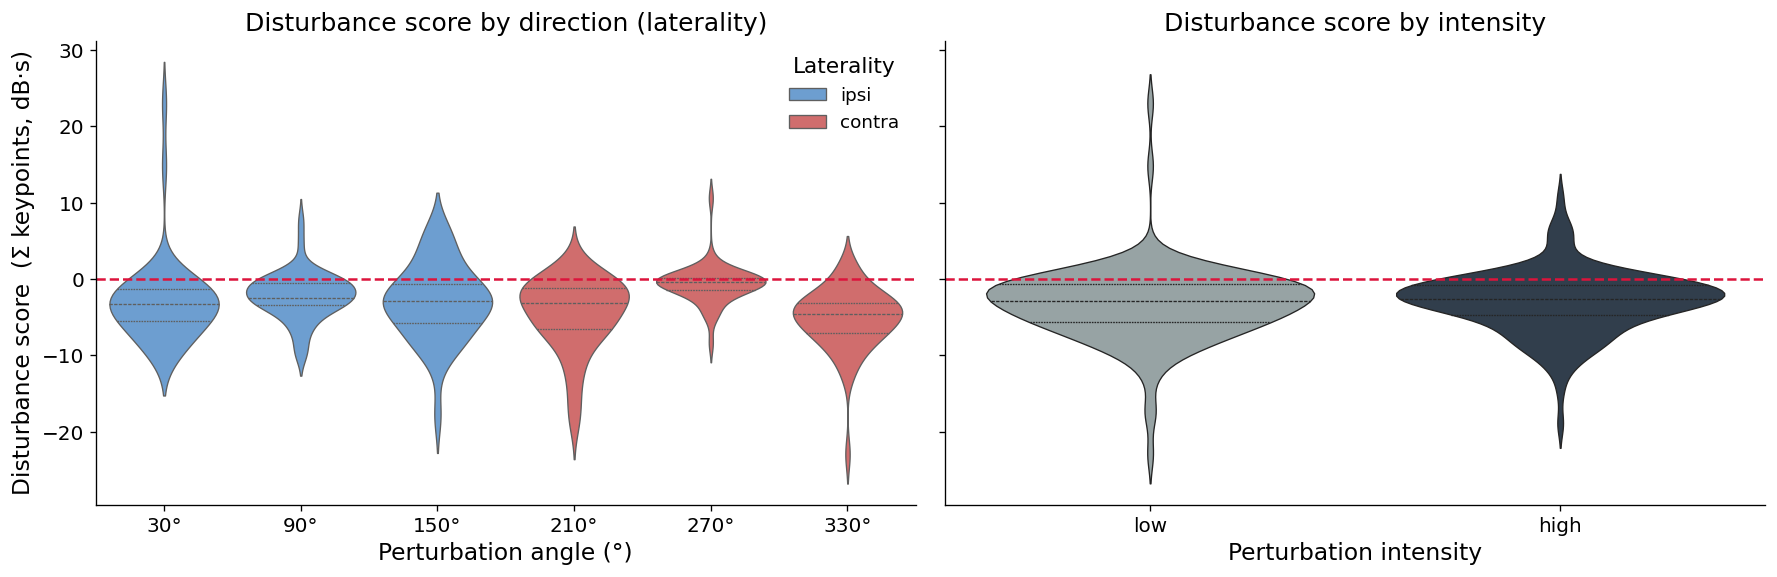

In [14]:
## ── Fig 4 · Disturbance score by direction & laterality ─────────────────────
directions  = df_tr["values_Sol_direction"].values
angles      = np.array([Params.sol_dir_to_angle[d] for d in directions])
laterality  = np.array([Params.sol_dir_to_contra_ipse[d] for d in directions])
levels      = np.array([Params.sol_dir_to_level[d] for d in directions])
ds_vals     = disturbances   # (n_trials,) – sum across keypoints

# build a tidy DataFrame for seaborn
plot_df = pd.DataFrame({
    "disturb_score": ds_vals,
    "direction": directions,
    "angle": angles,
    "laterality": ["contra" if x == 1 else "ipsi" for x in laterality],
    "intensity": ["high" if x == 1 else "low" for x in levels],
})
plot_df["dir_label"] = plot_df["angle"].astype(str) + "°"

angle_order = [str(Params.sol_dir_to_angle[d]) + "°" for d in range(12) if d < 5 or d == 11]
# use unique sorted angles as order
angle_order = sorted(plot_df["dir_label"].unique(),
                     key=lambda s: int(s.replace("°", "")))

with mpl.rc_context(PRES_RC):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    palette_lat = {"contra": "#e05c5c", "ipsi": "#5c9ee0"}
    palette_int = {"high": "#2c3e50", "low": "#95a5a6"}

    # left: by direction, coloured by laterality
    sns.violinplot(
        data=plot_df, x="dir_label", y="disturb_score", hue="laterality",
        order=angle_order, palette=palette_lat, inner="quartile",
        split=False, density_norm="width", ax=axes[0], linewidth=0.8,
    )
    axes[0].axhline(0, color="crimson", linestyle="--", lw=1.5)
    axes[0].set_xlabel("Perturbation angle (°)")
    axes[0].set_ylabel("Disturbance score  (Σ keypoints, dB·s)")
    axes[0].set_title("Disturbance score by direction (laterality)")
    axes[0].legend(title="Laterality", frameon=False, fontsize=11)

    # right: by intensity
    sns.violinplot(
        data=plot_df, x="intensity", y="disturb_score",
        palette=palette_int, inner="quartile",
        order=["low", "high"], density_norm="width", ax=axes[1], linewidth=0.8,
    )
    axes[1].axhline(0, color="crimson", linestyle="--", lw=1.5)
    axes[1].set_xlabel("Perturbation intensity")
    axes[1].set_ylabel("")
    axes[1].set_title("Disturbance score by intensity")

    fig.tight_layout()
    plt.show()


In [15]:
plot_df

,disturb_score,direction,angle,laterality,intensity,dir_label
0,-9.699029,4,90,ipsi,low,90°
1,0.108410,10,90,ipsi,high,90°
2,-6.711217,9,30,ipsi,high,30°
3,-6.124764,2,330,contra,low,330°
4,-1.023633,6,210,contra,high,210°
...,...,...,...,...,...,...
245,1.756437,0,150,ipsi,low,150°
246,0.433831,11,270,contra,low,270°
247,0.249406,8,330,contra,high,330°
248,-6.209492,1,210,contra,low,210°


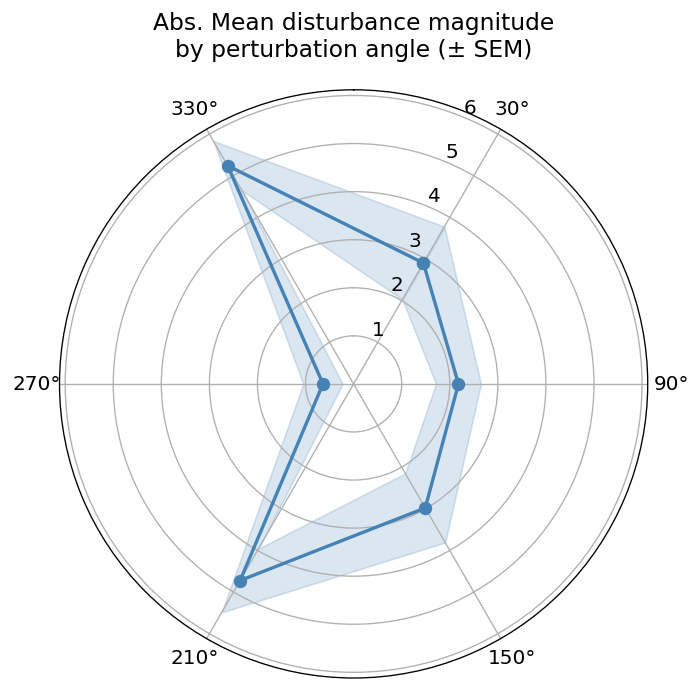

In [16]:
## ── Fig 5 · Polar plot — mean disturbance magnitude by angle ─────────────────
unique_angles = sorted({Params.sol_dir_to_angle[d] for d in range(12)})
mean_by_angle, sem_by_angle = [], []
for ang in unique_angles:
    vals = plot_df.loc[plot_df["angle"] == ang, "disturb_score"].values
    mean_by_angle.append(vals.mean())
    sem_by_angle.append(vals.std() / np.sqrt(len(vals)))

mean_by_angle = np.array(mean_by_angle)
sem_by_angle  = np.array(sem_by_angle)

# convert to radians (note: perturbation angles use compass convention → flip for polar)
theta = np.deg2rad(unique_angles)
# close the loop
theta_loop = np.append(theta, theta[0])
mag_loop   = np.append(-mean_by_angle, -mean_by_angle[0])   # flip sign: more negative = bigger effect
sem_loop   = np.append(sem_by_angle,  sem_by_angle[0])

with mpl.rc_context(PRES_RC):
    fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(6, 6))
    ax.plot(theta_loop, mag_loop, "o-", color="steelblue", lw=2, markersize=7)
    ax.fill_between(theta_loop, mag_loop - sem_loop, mag_loop + sem_loop,
                    alpha=0.2, color="steelblue")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(theta)
    ax.set_xticklabels([f"{a}°" for a in unique_angles])
    ax.set_title("Abs. Mean disturbance magnitude\nby perturbation angle (± SEM)",
                 pad=20, fontsize=14)
    plt.tight_layout()
    plt.show()


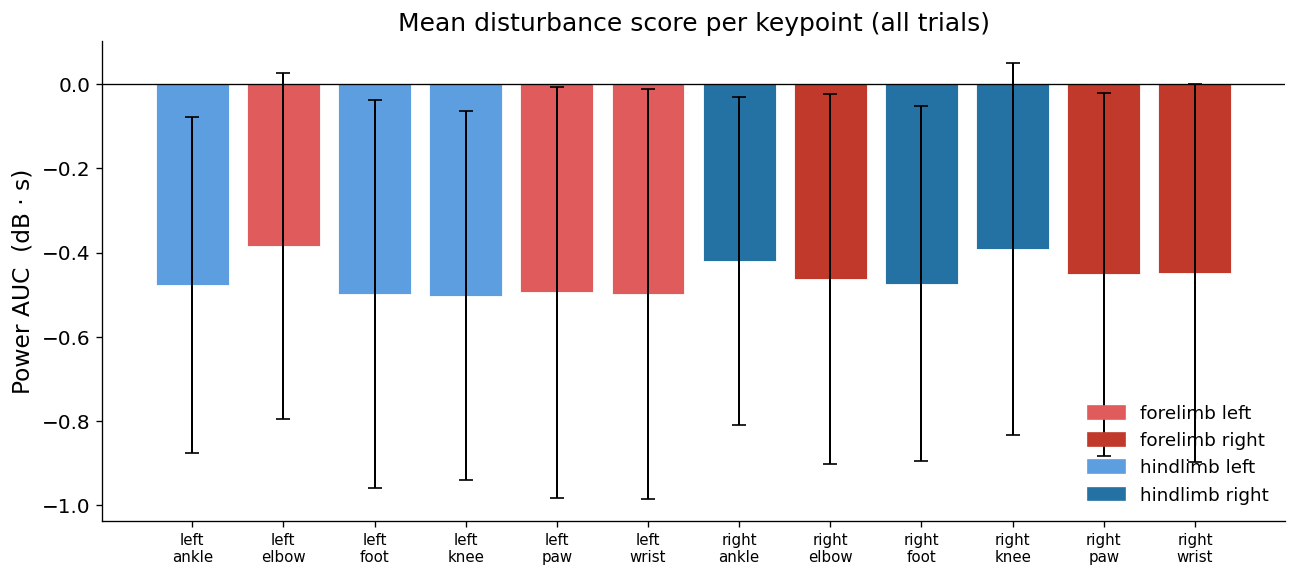

In [26]:
## ── Fig 6 · Per-keypoint power AUC (mean ± std) ─────────────────────────────
# score_mat shape: (n_trials, n_keypoints)
kp_mean_auc = score_mat.mean(axis=0)
kp_std_auc  = score_mat.std(axis=0)

fore_mask = np.array([any(k in f for k in FORE_KEYWORDS) for f in ALL_BHV_FIELDS])
hind_mask = ~fore_mask
left_mask = np.array(["left" in f for f in ALL_BHV_FIELDS])
right_mask = ~left_mask

kp_colors = np.where(
    fore_mask & left_mask, "#e05c5c",
    np.where(fore_mask & right_mask, "#c0392b",
    np.where(hind_mask & left_mask, "#5c9ee0", "#2471a3"))
)
label_map = {
    "#e05c5c":  "forelimb left",
    "#c0392b":  "forelimb right",
    "#5c9ee0":  "hindlimb left",
    "#2471a3":  "hindlimb right",
}

with mpl.rc_context(PRES_RC):
    fig, ax = plt.subplots(figsize=(11, 5))
    short_labels = [f.replace("_", "\n") for f in ALL_BHV_FIELDS]
    bars = ax.bar(np.arange(len(ALL_BHV_FIELDS)), kp_mean_auc,
                  color=kp_colors, edgecolor="white", linewidth=0.5)
    ax.errorbar(np.arange(len(ALL_BHV_FIELDS)), kp_mean_auc, yerr=kp_std_auc,
                fmt="none", color="black", capsize=4, elinewidth=1.2)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(np.arange(len(ALL_BHV_FIELDS)))
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_ylabel("Power AUC  (dB · s)")
    ax.set_title("Mean disturbance score per keypoint (all trials)")

    # legend
    from matplotlib.patches import Patch
    handles = [Patch(color=c, label=l) for c, l in label_map.items()]
    ax.legend(handles=handles, frameon=False, fontsize=11, loc="lower right")

    fig.tight_layout()
    plt.show()
